In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo de gráficos
sns.set_theme(style="white")
print("Librerías cargadas y entorno configurado.")

Librerías cargadas y entorno configurado.


In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/karlaazuniga/2516662022_Zuniga_Karla/refs/heads/main/dataset/clave_H_correlacion.csv", sep=',')


In [4]:
print(f"Dataset cargado con éxito. Total de registros: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\n--- VISTA DE LAS PRIMERAS 5 FILAS ---")
print(df.head())

Dataset cargado con éxito. Total de registros: 256 | Columnas: 1

--- VISTA DE LAS PRIMERAS 5 FILAS ---
  cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0       H-C0001,53,867,5,53.63,8.09,2,3,18.49,296.27                                                                               
1      H-C0002,31,1134,7,68.46,9.43,0,5,29.04,466.41                                                                               
2      H-C0003,58,1635,5,81.71,5.95,4,3,20.85,399.02                                                                               
3      H-C0004,38,1185,9,77.26,6.91,3,7,23.43,615.29                                                                               
4       H-C0005,49,1276,11,88.71,8.34,0,9,8.2,914.97                                                                               


In [7]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("--- VARIABLES NUMÉRICAS IDENTIFICADAS ---")
for idx, var in enumerate(variables_numericas, 1):
    print(f"{idx}. {var} ({df[var].dtype})")

--- VARIABLES NUMÉRICAS IDENTIFICADAS ---
1. edad (int64)
2. ingresos_mensuales (int64)
3. frecuencia_compra (int64)
4. ticket_promedio (float64)
5. satisfaccion (float64)
6. reclamos (int64)
7. uso_app (int64)
8. tiempo_respuesta (float64)
9. consumo_total (float64)


In [9]:
print("--- 1. DETECCIÓN DE VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- 2. DETECCIÓN DE REGISTROS DUPLICADOS ---")
duplicados = df.duplicated().sum()
print(f"Cantidad de filas duplicadas exactas: {duplicados}")

# --- Proceso de Limpieza y Consistencia ---
# Remover duplicados
df_clean = df.drop_duplicates()

--- 1. DETECCIÓN DE VALORES NULOS ---
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

--- 2. DETECCIÓN DE REGISTROS DUPLICADOS ---
Cantidad de filas duplicadas exactas: 1


In [10]:
# Imputar valores nulos con la mediana de cada columna numérica
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

In [11]:
print("\n--- 3. ANÁLISIS DE VALORES ATÍPICOS (MÉTODO IQR) ---")
for col in variables_numericas:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < limite_inferior) | (df_clean[col] > limite_superior)]
    print(f"Variable '{col}': {len(outliers)} valores atípicos identificados.")

print("\nTratamiento completado: Dataset limpio, consistente y listo para análisis.")


--- 3. ANÁLISIS DE VALORES ATÍPICOS (MÉTODO IQR) ---
Variable 'edad': 3 valores atípicos identificados.
Variable 'ingresos_mensuales': 0 valores atípicos identificados.
Variable 'frecuencia_compra': 3 valores atípicos identificados.
Variable 'ticket_promedio': 4 valores atípicos identificados.
Variable 'satisfaccion': 7 valores atípicos identificados.
Variable 'reclamos': 28 valores atípicos identificados.
Variable 'uso_app': 6 valores atípicos identificados.
Variable 'tiempo_respuesta': 4 valores atípicos identificados.
Variable 'consumo_total': 7 valores atípicos identificados.

Tratamiento completado: Dataset limpio, consistente y listo para análisis.


In [12]:
matriz_correlacion = df_clean[variables_numericas].corr()

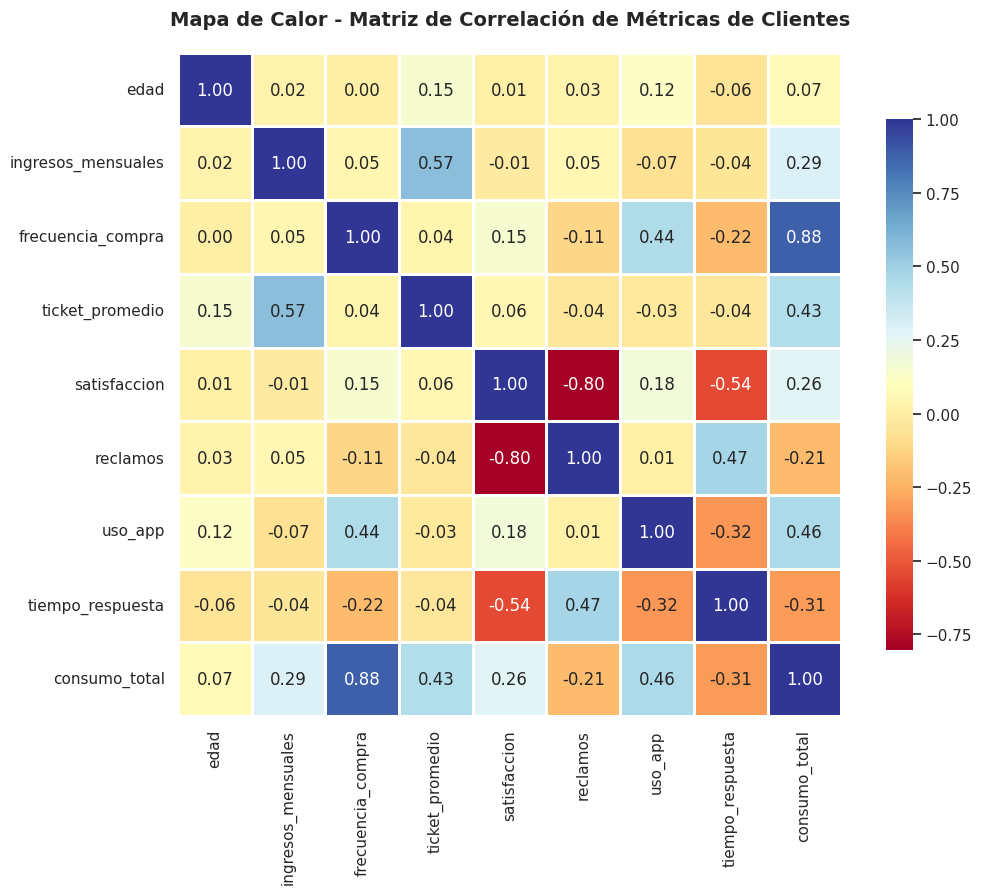

In [13]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='RdYlBu',
    fmt=".2f",
    linewidths=0.8,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Mapa de Calor - Matriz de Correlación de Métricas de Clientes', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

In [14]:
plt.savefig('mapa_calor_correlacion.png', bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>